In [1]:
using PyCall
pyimport_conda("scienceplots", "scienceplots", "conda-forge")
sp = pyimport("scienceplots")


PyObject <module 'scienceplots' from '/Users/harukiyamamoto/.julia/conda/3/aarch64/lib/python3.12/site-packages/scienceplots/__init__.py'>

In [2]:
using Revise 
using ShipMMG
# using Plots, StatsPlots
using Turing, DifferentialEquations, ForwardDiff, Bijectors, DomainSets
using CSV, Random, DataFrames, Distributions, StatsBase
using ProgressMeter
using LinearAlgebra
using PyPlot, LaTeXStrings, PyCall
@pyimport numpy as np
@pyimport scienceplots

using Pkg
Pkg.status("ShipMMG")

Project ShipMMG v0.0.8
No Matches in `~/Documents/M1/ShipMMG.jl/Project.toml`
ShipMMG v0.0.8
No Matches in `~/Documents/M1/ShipMMG.jl/Project.toml`


In [3]:
basic_params = get_KCS_basic_params()
maneuvering_params = get_KCS_maneuvering_params()
wind_coef_prams = get_example_KCS_ship_wind_force_moment_params()
L_pp = basic_params.L_pp
B = basic_params.B
d = basic_params.d

0.143

In [4]:
print(maneuvering_params.R_0_dash)

0.0167

In [5]:
case = "sin" # "zigzagg" or "turn"
δ = 35 #deg
duration = 100
noise = "B"
wind = 0

0

In [6]:
if case == "turn"

    max_δ_rad = δ * pi / 180.0  # [rad]
    n_const = 15  # [rps]
    # n_const = 21.21824  # [rps]

    sampling = duration * 10
    time_list = range(0.00, stop=duration, length=sampling)
    δ_rad_list = max_δ_rad .* ones(Float64, sampling)
    n_p_list = n_const .* ones(Float64, sampling)
    U_W_list = wind .* ones(Float64, sampling) ./5
    ψ_W_list = deg2rad.(0 .* ones(Float64, sampling))


    mmg_results = mmg_3dof_simulate(
        basic_params,
        maneuvering_params,
        wind_coef_prams,
        time_list,
        δ_rad_list,
        n_p_list,
        U_W_list,
        ψ_W_list,
        u0=1.25,
        # u0=1.441442,
        v0=0.0,
        r0=0.0,
    )
    u, v, r, x, y, ψ, δ, n_p = mmg_results
    x_true, y_true, ψ_true = calc_position(time_list, u, v, r)

elseif case == "sin"

    n_const = 15  # [rps]
    # n_const = 21.21824  # [rps]

    sampling = duration * 10
    time_list = range(0.00, stop=duration, length=sampling)
    #time_listの中でSin関数を使ってδを変化させる
    
    δ_rad_list = δ .* sin.(time_list./(100/4pi)) .* pi / 180.0
    n_p_list = n_const .* ones(Float64, sampling)
    U_W_list = wind .* ones(Float64, sampling) ./5
    ψ_W_list = deg2rad.(0 .* ones(Float64, sampling))


    mmg_results = mmg_3dof_simulate(
        basic_params,
        maneuvering_params,
        wind_coef_prams,
        time_list,
        δ_rad_list,
        n_p_list,
        U_W_list,
        ψ_W_list,
        u0=1.25,
        # u0=1.441442,
        v0=0.0,
        r0=0.0,
        Ψ0= -0.0 * pi / 180.0,
    )
    u, v, r, x, y, ψ, δ, n_p = mmg_results
    x_true, y_true, ψ_true = x, y, ψ
end

df = DataFrame(
    time = time_list,
    u = u,
    v = v,
    r = r,
    δ = δ,
    n_p = n_p_list,
    x_true = x_true,
    y_true = y_true,
    ψ_true = ψ_true,
    U_W = U_W_list,
    ψ_W = ψ_W_list,
)

CSV.write("data/kcs_model_true_data1.csv", df)

"data/kcs_model_true_data1.csv"

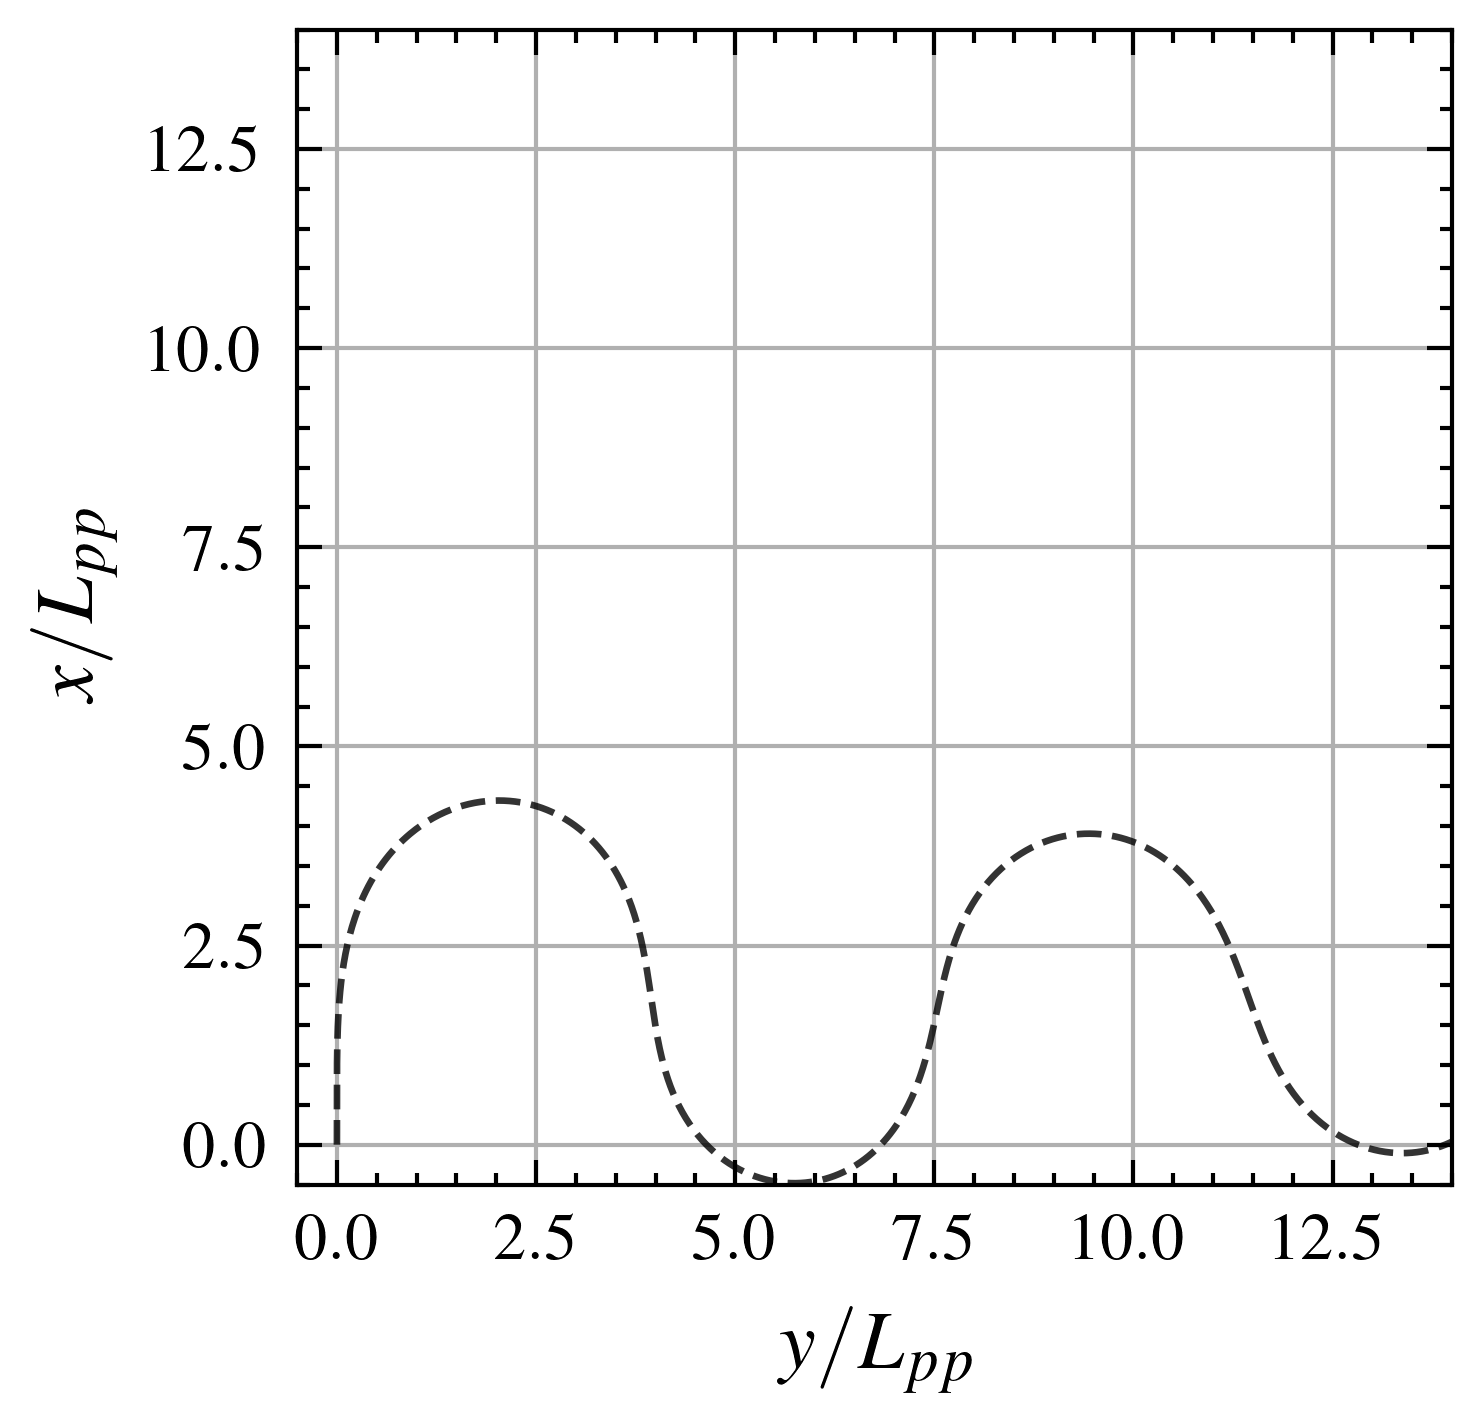

In [7]:
plt.style.use(["science", "ieee"])

fig = plt.figure(figsize=(2.5, 2.5))

xticks = [0, 2.5, 5, 7.5, 10, 12.5]
yticks = [0, 2.5, 5, 7.5, 10, 12.5]
xlim = (-0.5, 14)
ylim = (-0.5, 14)

ax = fig.add_subplot(1, 1, 1)
ax.plot(y_true/L_pp, x_true/L_pp, "--", label="observation", c="k", alpha=0.8, linewidth=0.8)
ax.set_ylabel(L"x/L_{pp}", fontsize=10)
ax.set_xlabel(L"y/L_{pp}", fontsize=10)
ax.axis("scaled")
ax.set_xticks(xticks)
ax.set_yticks(yticks)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.grid()
display(fig)

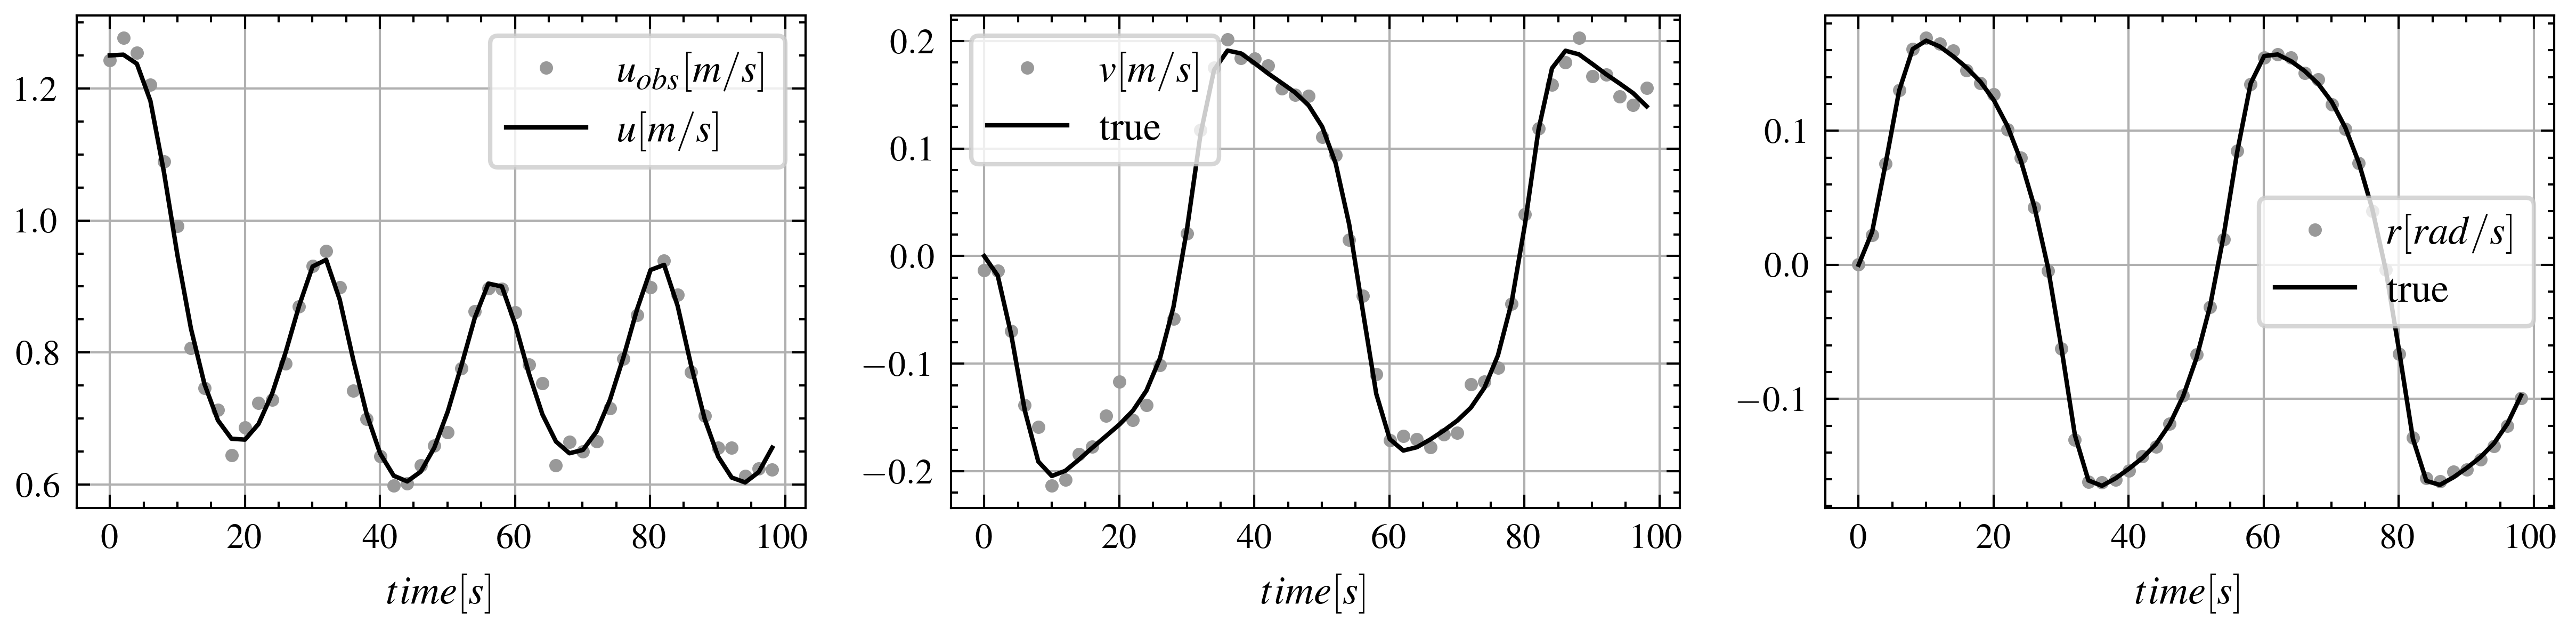

In [8]:
sampling_rate = 0.5


#データの読み込み
readname = "data/kcs_model_true_data1.csv"
df = CSV.read(readname, DataFrame)
df = df[completecases(df), :]
sampling = Int(length(df[:,1])/(duration*sampling_rate))

df = df[1:sampling:end,:]

time_list = df[!,"time"]
u = df[!,"u"]
v = df[!,"v"]
r = df[!,"r"]
δ = df[!,"δ"]
n_p = df[!,"n_p"]
x = df[!,"x_true"]
y = df[!,"y_true"]
ψ = df[!,"ψ_true"]
U_W = df[!,"U_W"]
ψ_W = df[!,"ψ_W"]

if noise == "A"
    u_obs = u + rand(Normal(0.0, 0.005), length(u))
    v_obs = v + rand(Normal(0.0, 0.0025), length(v))
    r_obs = r + rand(Normal(0.0, 0.0005), length(r))
elseif noise == "B"
    u_obs = u + rand(Normal(0.0, 0.02), length(u))
    v_obs = v + rand(Normal(0.0, 0.01), length(v))
    r_obs = r + rand(Normal(0.0, 0.002), length(r))
elseif noise == "C"
    u_obs = u + rand(Normal(0.0, 0.08), length(u))
    v_obs = v + rand(Normal(0.0, 0.04), length(v))
    r_obs = r + rand(Normal(0.0, 0.008), length(r))
elseif noise == "D"
    u_obs = u + rand(Normal(0.0, 0.32), length(u))
    v_obs = v + rand(Normal(0.0, 0.16), length(v))
    r_obs = r + rand(Normal(0.0, 0.032), length(r))
else
    u_obs = u
    v_obs = v
    r_obs = r
end

df = DataFrame(
    time = time_list,
    u = u_obs,
    v = v_obs,
    r = r_obs,
)

CSV.write("data/kcs_model_obs_data1.csv", df)

shipdata = ShipData(time_list, u_obs, v_obs, r_obs, r.*0, r.*0, ψ, δ, n_p)
envdata = EnvironmentData(time_list, U_W, ψ_W)

fig = plt.figure(figsize=(10,2))
ax = fig.add_subplot(1, 3, 1)
ax.plot(time_list[:], u_obs[:],label=L"u_{obs}[m/s]", "o", c="0.6", markersize=2)
ax.plot(time_list[:], u[:], label=L"u[m/s]", "-", c="k", linewidth=1)
ax.legend(frameon=true, fontsize=9)
ax.set_xlabel(L"time[s]", fontsize=9)
ax.grid()

ax = fig.add_subplot(1, 3, 2)
ax.plot(time_list[:], v_obs[:],label=L"v[m/s]", "o", c="0.6", markersize=2)
ax.plot(time_list[:], v[:], label="true", "-", c="k", linewidth=1)
ax.legend(frameon=true, fontsize=9)
ax.set_xlabel(L"time[s]", fontsize=9)
ax.grid()

ax = fig.add_subplot(1, 3, 3)
ax.plot(time_list[:], r_obs[:],label=L"r[rad/s]", "o", c="0.6", markersize=2)
ax.plot(time_list[:], r[:], label="true", "-", c="k", linewidth=1)
ax.legend(frameon=true, fontsize=9)
ax.set_xlabel(L"time[s]", fontsize=9)
ax.grid()
display(fig)

In [9]:
n_chains = 4
n_samples = 1000

priors = Dict(
    :R_0_dash => Uniform(0.000, 0.100),
    :X_vv_dash => Uniform(-0.200, 0.200),
    :X_vr_dash => Uniform(-0.223, 0.177),
    :X_rr_dash => Uniform(-0.088, 0.32),
    :X_vvvv_dash => Uniform(-1.400, 1.400),
    :Y_v_dash => Uniform(-0.500, 0.000),
    :Y_r_dash => Uniform(-0.100, 0.200),
    :Y_vvv_dash => Uniform(-6.000, 2.000),
    :Y_vvr_dash => Uniform(-2.500, 1.000),
    :Y_vrr_dash => Uniform(-1.500, 0.000),
    :Y_rrr_dash => Uniform(-0.120, 0.040),
    :N_v_dash => Uniform(-0.200, 0.000),
    :N_r_dash => Uniform(-0.100, 0.000),
    :N_vvv_dash => Uniform(-0.500, 0.400),
    :N_vvr_dash => Uniform(-1.000, 0.000),
    :N_vrr_dash => Uniform(-0.300, 0.300),
    :N_rrr_dash => Uniform(-0.060, 0.000)
)

initial_values = Dict(
    :R_0_dash => maneuvering_params.R_0_dash,
    :X_vv_dash => maneuvering_params.X_vv_dash,
    :X_vr_dash => maneuvering_params.X_vr_dash,
    :X_rr_dash => maneuvering_params.X_rr_dash,
    :X_vvvv_dash => maneuvering_params.X_vvvv_dash,
    :Y_v_dash => maneuvering_params.Y_v_dash,
    :Y_r_dash => maneuvering_params.Y_r_dash,
    :Y_vvv_dash => maneuvering_params.Y_vvv_dash,
    :Y_vvr_dash => maneuvering_params.Y_vvr_dash,
    :Y_vrr_dash => maneuvering_params.Y_vrr_dash,
    :Y_rrr_dash => maneuvering_params.Y_rrr_dash,
    :N_v_dash => maneuvering_params.N_v_dash,
    :N_r_dash => maneuvering_params.N_r_dash,
    :N_vvv_dash => maneuvering_params.N_vvv_dash,
    :N_vvr_dash => maneuvering_params.N_vvr_dash,
    :N_vrr_dash => maneuvering_params.N_vrr_dash,
    :N_rrr_dash => maneuvering_params.N_rrr_dash
)

model = []
model = create_model_for_mcmc_sample_mmg(
    shipdata,
    envdata,
    basic_params,
    wind_coef_prams,
    maneuvering_params.k_0,
    maneuvering_params.k_1,
    maneuvering_params.k_2,
    ρ=1025.0,
    σ_u_prior_dist = Uniform(0.0, 1.0),
    σ_v_prior_dist = Uniform(0.0, 1.0),
    σ_r_prior_dist = Uniform(0.0, 1.0),
    R_0_dash_prior_dist = priors[:R_0_dash],
    X_vv_dash_prior_dist = priors[:X_vv_dash],
    X_vr_dash_prior_dist = priors[:X_vr_dash],
    X_rr_dash_prior_dist = priors[:X_rr_dash],
    X_vvvv_dash_prior_dist = priors[:X_vvvv_dash],
    Y_v_dash_prior_dist = priors[:Y_v_dash],
    Y_r_dash_prior_dist = priors[:Y_r_dash],
    Y_vvv_dash_prior_dist = priors[:Y_vvv_dash],
    Y_vvr_dash_prior_dist = priors[:Y_vvr_dash],
    Y_vrr_dash_prior_dist = priors[:Y_vrr_dash],
    Y_rrr_dash_prior_dist = priors[:Y_rrr_dash],
    N_v_dash_prior_dist = priors[:N_v_dash],
    N_r_dash_prior_dist = priors[:N_r_dash],
    N_vvv_dash_prior_dist = priors[:N_vvv_dash],
    N_vvr_dash_prior_dist = priors[:N_vvr_dash],
    N_vrr_dash_prior_dist = priors[:N_vrr_dash],
    N_rrr_dash_prior_dist = priors[:N_rrr_dash]
)

chain = []
chain = sample(model, NUTS(500, 0.65), MCMCThreads(), n_samples, n_chains, progress = true)

chain_array = Array(chain)
coefficient_list = DataFrame(chain_array,[:sigma_u, :sigma_v, :sigma_r, :R_0, :X_vv, :X_vr, :X_rr, :X_vvvv, :Y_v, :Y_r, :Y_vvv, :Y_vvr, :Y_vrr, :Y_rrr, :N_v, :N_r, :N_vvv, :N_vvr, :N_vrr, :N_rrr])
CSV.write("data/30sint_B_s2.csv", coefficient_list)

┌ Warning: Only a single thread available: MCMC chains are not sampled in parallel
└ @ AbstractMCMC /Users/harukiyamamoto/.julia/packages/AbstractMCMC/1gucv/src/sample.jl:432
Sampling (1 thread)   0%|                               |  ETA: N/A
┌ Info: Found initial step size
│   ϵ = 0.2
└ @ Turing.Inference /Users/harukiyamamoto/.julia/packages/Turing/GSvwQ/src/mcmc/hmc.jl:213
┌ Warning: At t=12.939708068034715, dt was forced below floating point epsilon 1.7763568394002505e-15, and step error estimate = 2.9281823853077853. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of ForwardDiff.Dual{ForwardDiff.Tag{DynamicPPL.DynamicPPLTag, Float64}, Float64, 10}).
└ @ SciMLBase /Users/harukiyamamoto/.julia/packages/SciMLBase/u2Ue2/src/integrator_interface.jl:623

┌ Info: Found initial step size
│   ϵ = 0.2
└ @ Turing.Inference /Users/harukiyamamoto/.julia/packages/Turing/GSvwQ/src/mcmc/h

"data/30sint_B_s2.csv"

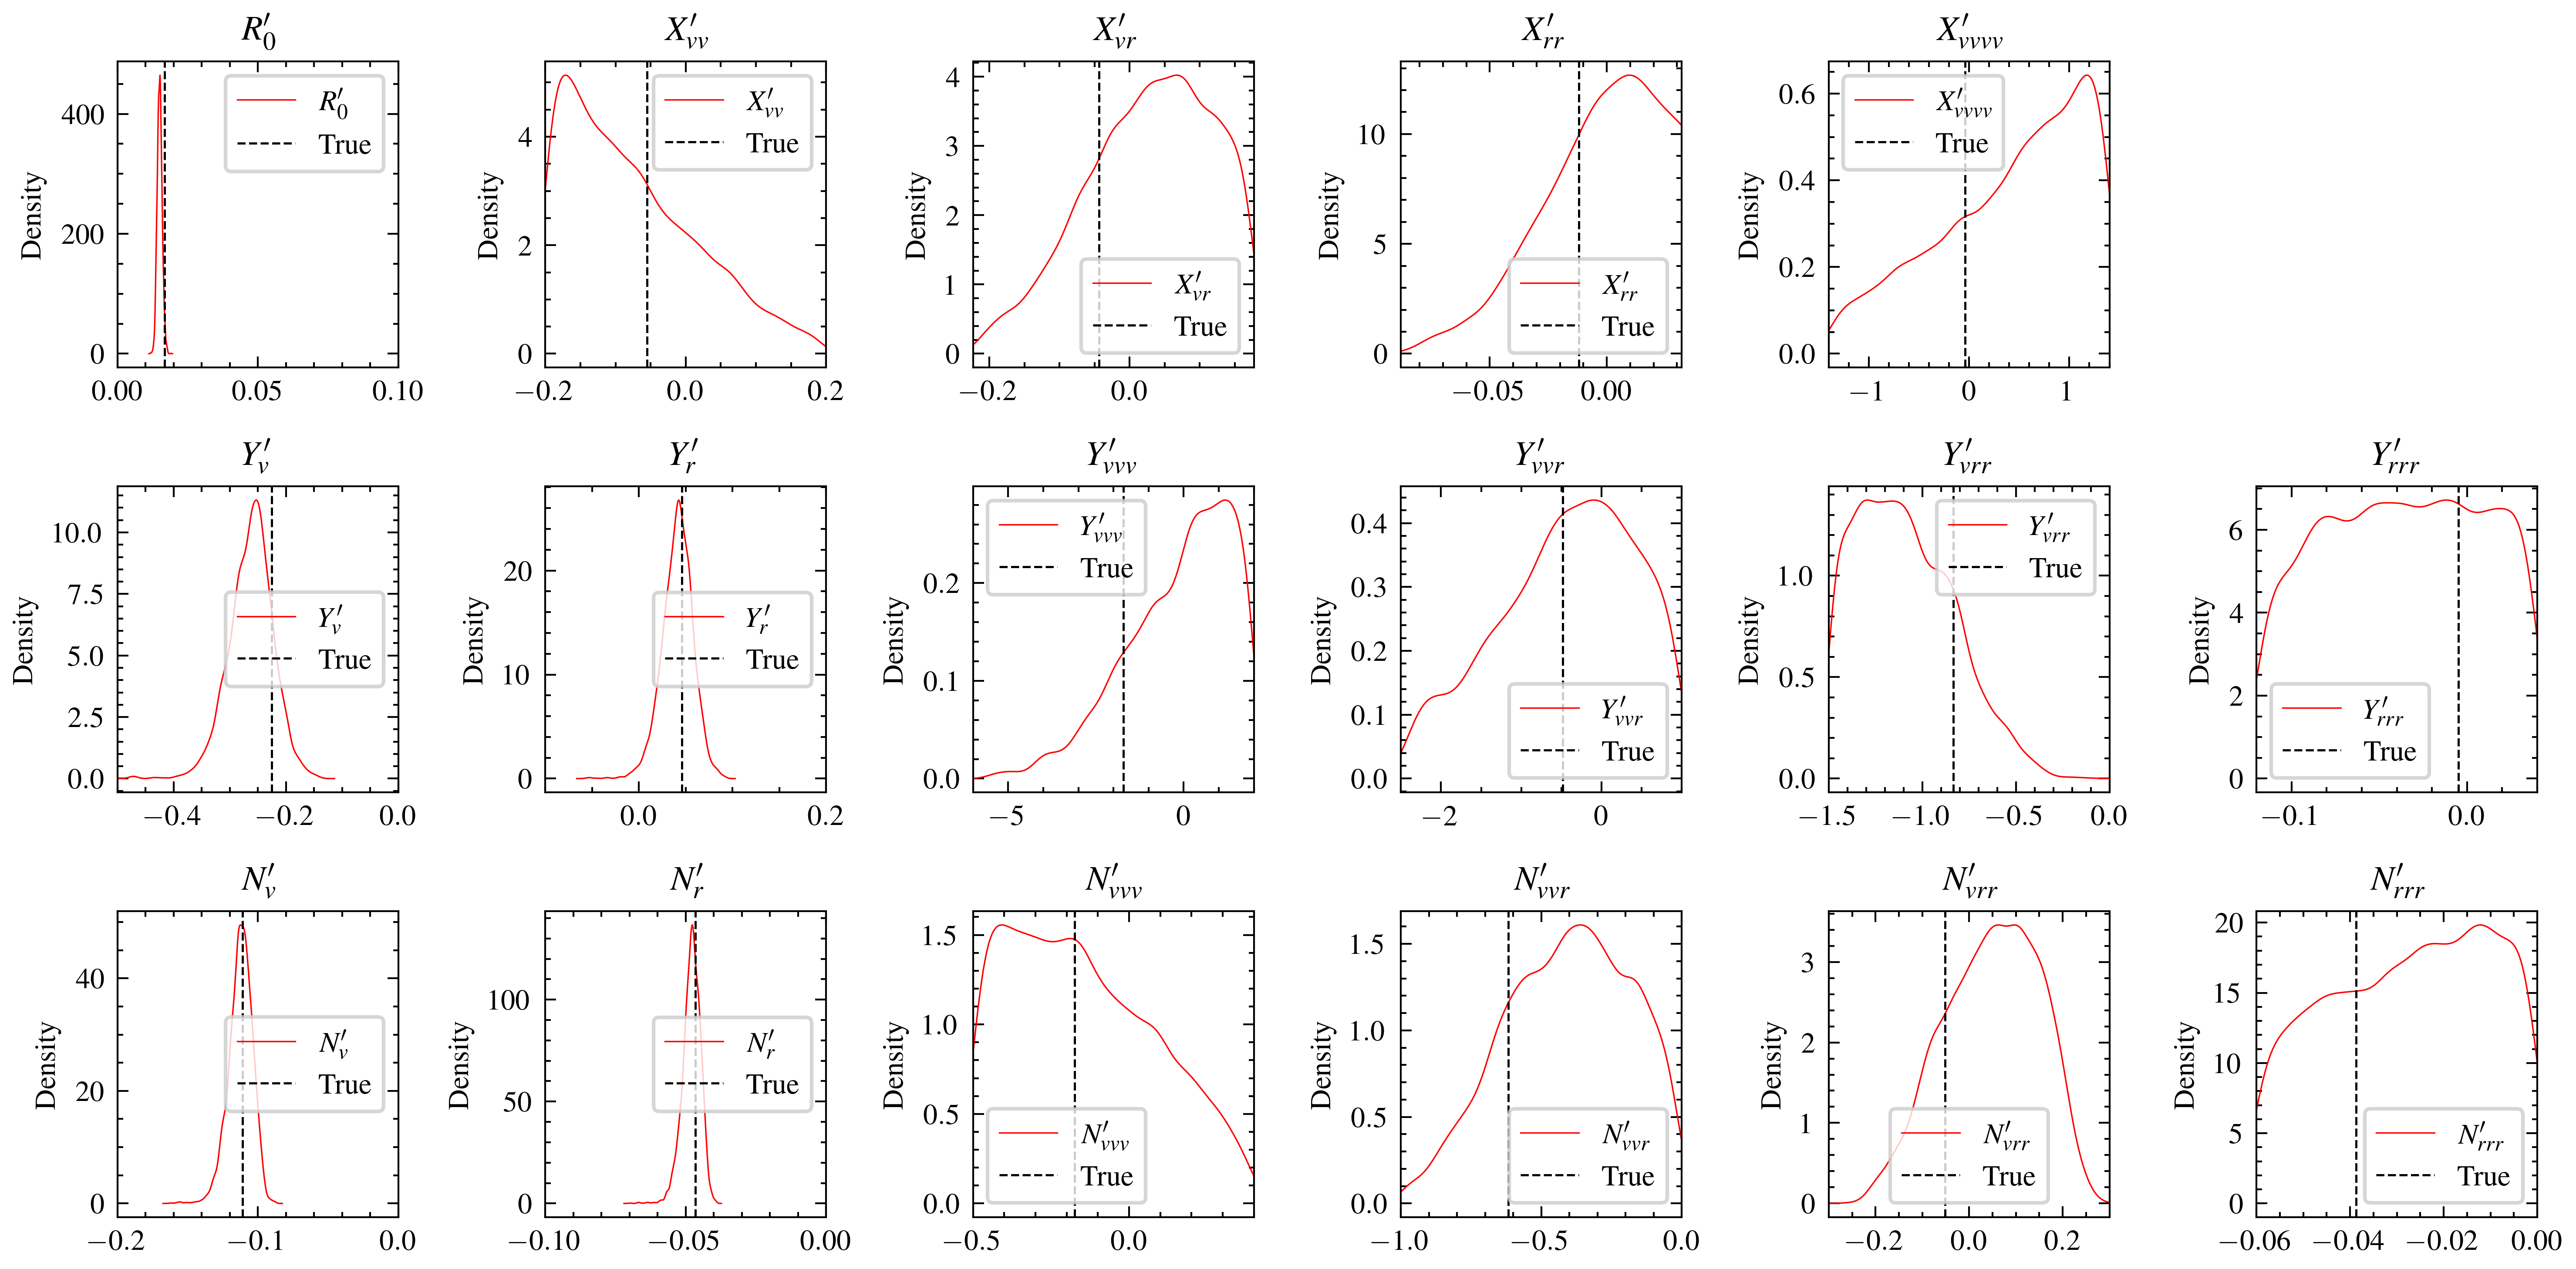

In [16]:
using KernelDensity: kde
# データの読み込み
data = CSV.read("data/30sint_B_s2.csv", DataFrame)
fig = plt.figure(figsize=(10, 5))
start_num = 1
end_num = 4000
# R_0_dash
R_0_posterior = data.R_0[start_num:end_num]
kde_result = kde(R_0_posterior)
ax = fig.add_subplot(3, 6, 1)
ax.plot(kde_result.x, kde_result.density, label=L"R_0^{\prime}", c="r", linewidth=0.4)
ax.axvline(x=0.0167, c="k", linestyle="--", label="True", linewidth=0.6)
ax.set_ylabel(L"\textrm{Density}")
ax.set_title(L"R_0^{\prime}")
ax.legend(frameon=true)
ax.set_xlim(0.00, 0.10)

# X_vv_dash
X_vv_posterior = data.X_vv[start_num:end_num]
kde_result = kde(X_vv_posterior)
ax = fig.add_subplot(3, 6, 2)
ax.plot(kde_result.x, kde_result.density, label=L"X_{vv}^{\prime}", c="r", linewidth=0.4)
ax.axvline(x=-0.0549, c="k", linestyle="--", label="True", linewidth=0.6)
ax.set_ylabel(L"\textrm{Density}")
ax.set_title(L"X_{vv}^{\prime}")
ax.legend(frameon=true)
ax.set_xlim(-0.20, 0.20)

# X_vr_dash
X_vr_posterior = data.X_vr[start_num:end_num]
kde_result = kde(X_vr_posterior)
ax = fig.add_subplot(3, 6, 3)
ax.plot(kde_result.x, kde_result.density, label=L"X_{vr}^{\prime}", c="r", linewidth=0.4)
ax.axvline(x=-0.0437, c="k", linestyle="--", label="True", linewidth=0.6)
ax.set_ylabel(L"\textrm{Density}")
ax.set_title(L"X_{vr}^{\prime}")
ax.legend(frameon=true)
ax.set_xlim(-0.223, 0.177)

# X_rr_dash
X_rr_posterior = data.X_rr[start_num:end_num]
kde_result = kde(X_rr_posterior)
ax = fig.add_subplot(3, 6, 4)
ax.plot(kde_result.x, kde_result.density, label=L"X_{rr}^{\prime}", c="r", linewidth=0.4)
ax.axvline(x=-0.0120, c="k", linestyle="--", label="True", linewidth=0.6)
ax.set_ylabel(L"\textrm{Density}")
ax.set_title(L"X_{rr}^{\prime}")
ax.legend(frameon=true)
ax.set_xlim(-0.088, 0.032)

# X_vvvv_dash
X_vvvv_posterior = data.X_vvvv[start_num:end_num]
kde_result = kde(X_vvvv_posterior)
ax = fig.add_subplot(3, 6, 5)
ax.plot(kde_result.x, kde_result.density, label=L"X_{vvvv}^{\prime}", c="r", linewidth=0.4)
ax.axvline(x=-0.0417, c="k", linestyle="--", label="True", linewidth=0.6)
ax.set_ylabel(L"\textrm{Density}")
ax.set_title(L"X_{vvvv}^{\prime}")
ax.legend(frameon=true)
ax.set_xlim(-1.40, 1.40)

# Y_v_dash
Y_v_posterior = data.Y_v[start_num:end_num]
kde_result = kde(Y_v_posterior)
ax = fig.add_subplot(3, 6, 7)
ax.plot(kde_result.x, kde_result.density, label=L"Y_{v}^{\prime}", c="r", linewidth=0.4)
ax.axvline(x=-0.2252, c="k", linestyle="--", label="True", linewidth=0.6)
ax.set_ylabel(L"\textrm{Density}")
ax.set_title(L"Y_{v}^{\prime}")
ax.legend(frameon=true)
ax.set_xlim(-0.50, 0.00)

# Y_r_dash
Y_r_posterior = data.Y_r[start_num:end_num]
kde_result = kde(Y_r_posterior)
ax = fig.add_subplot(3, 6, 8)
ax.plot(kde_result.x, kde_result.density, label=L"Y_{r}^{\prime}", c="r", linewidth=0.4)
ax.axvline(x=0.0459, c="k", linestyle="--", label="True", linewidth=0.6)
ax.set_ylabel(L"\textrm{Density}")
ax.set_title(L"Y_{r}^{\prime}")
ax.legend(frameon=true)
ax.set_xlim(-0.10, 0.20)

# Y_vvv_dash
Y_vvv_posterior = data.Y_vvv[start_num:end_num]
kde_result = kde(Y_vvv_posterior)
ax = fig.add_subplot(3, 6, 9)
ax.plot(kde_result.x, kde_result.density, label=L"Y_{vvv}^{\prime}", c="r", linewidth=0.4)
ax.axvline(x=-1.7179, c="k", linestyle="--", label="True", linewidth=0.6)
ax.set_ylabel(L"\textrm{Density}")
ax.set_title(L"Y_{vvv}^{\prime}")
ax.legend(frameon=true)
ax.set_xlim(-6.00, 2.00)

# Y_vvr_dash
Y_vvr_posterior = data.Y_vvr[start_num:end_num]
kde_result = kde(Y_vvr_posterior)
ax = fig.add_subplot(3, 6, 10)
ax.plot(kde_result.x, kde_result.density, label=L"Y_{vvr}^{\prime}", c="r", linewidth=0.4)
ax.axvline(x=-0.4832, c="k", linestyle="--", label="True", linewidth=0.6)
ax.set_ylabel(L"\textrm{Density}")
ax.set_title(L"Y_{vvr}^{\prime}")
ax.legend(frameon=true)
ax.set_xlim(-2.50, 1.00)

# Y_vrr_dash
Y_vrr_posterior = data.Y_vrr[start_num:end_num]
kde_result = kde(Y_vrr_posterior)
ax = fig.add_subplot(3, 6, 11)
ax.plot(kde_result.x, kde_result.density, label=L"Y_{vrr}^{\prime}", c="r", linewidth=0.4)
ax.axvline(x=-0.8341, c="k", linestyle="--", label="True", linewidth=0.6)
ax.set_ylabel(L"\textrm{Density}")
ax.set_title(L"Y_{vrr}^{\prime}")
ax.legend(frameon=true)
ax.set_xlim(-1.50, 0.00)

# Y_rrr_dash
Y_rrr_posterior = data.Y_rrr[start_num:end_num]
kde_result = kde(Y_rrr_posterior)
ax = fig.add_subplot(3, 6, 12)
ax.plot(kde_result.x, kde_result.density, label=L"Y_{rrr}^{\prime}", c="r", linewidth=0.4)
ax.axvline(x=-0.0050, c="k", linestyle="--", label="True", linewidth=0.6)
ax.set_ylabel(L"\textrm{Density}")
ax.set_title(L"Y_{rrr}^{\prime}")
ax.legend(frameon=true)
ax.set_xlim(-0.12, 0.04)

# N_v_dash
N_v_posterior = data.N_v[start_num:end_num]
kde_result = kde(N_v_posterior)
ax = fig.add_subplot(3, 6, 13)
ax.plot(kde_result.x, kde_result.density, label=L"N_{v}^{\prime}", c="r", linewidth=0.4)
ax.axvline(x=-0.1111, c="k", linestyle="--", label="True", linewidth=0.6)
ax.set_ylabel(L"\textrm{Density}")
ax.set_title(L"N_{v}^{\prime}")
ax.legend(frameon=true)
ax.set_xlim(-0.20, 0.00)

# N_r_dash
N_r_posterior = data.N_r[start_num:end_num]
kde_result = kde(N_r_posterior)
ax = fig.add_subplot(3, 6, 14)
ax.plot(kde_result.x, kde_result.density, label=L"N_{r}^{\prime}", c="r", linewidth=0.4)
ax.axvline(x=-0.0465, c="k", linestyle="--", label="True", linewidth=0.6)
ax.set_ylabel(L"\textrm{Density}")
ax.set_title(L"N_{r}^{\prime}")
ax.legend(frameon=true)
ax.set_xlim(-0.10, 0.00)

# N_vvv_dash 
N_vvv_posterior = data.N_vvv[start_num:end_num]
kde_result = kde(N_vvv_posterior) 
ax = fig.add_subplot(3, 6, 15) 
ax.plot(kde_result.x, kde_result.density, label=L"N_{vvv}^{\prime}", c="r", linewidth=0.4)
ax.axvline(x=-0.1752, c="k", linestyle="--", label="True", linewidth=0.6) 
ax.set_ylabel(L"\textrm{Density}") 
ax.set_title(L"N_{vvv}^{\prime}") 
ax.legend(frameon=true) 
ax.set_xlim(-0.50, 0.40) 
# N_vvr_dash 
N_vvr_posterior = data.N_vvr[start_num:end_num]
kde_result = kde(N_vvr_posterior) 
ax = fig.add_subplot(3, 6, 16) 
ax.plot(kde_result.x, kde_result.density, label=L"N_{vvr}^{\prime}", c="r", linewidth=0.4) 
ax.axvline(x=-0.6168, c="k", linestyle="--", label="True", linewidth=0.6) 
ax.set_ylabel(L"\textrm{Density}") 
ax.set_title(L"N_{vvr}^{\prime}") 
ax.legend(frameon=true) 
ax.set_xlim(-1.00, 0.00) 
# N_vrr_dash 
N_vrr_posterior = data.N_vrr[start_num:end_num]
kde_result = kde(N_vrr_posterior) 
ax = fig.add_subplot(3, 6, 17) 
ax.plot(kde_result.x, kde_result.density, label=L"N_{vrr}^{\prime}", c="r", linewidth=0.4) 
ax.axvline(x=-0.0512, c="k", linestyle="--", label="True", linewidth=0.6) 
ax.set_ylabel(L"\textrm{Density}") 
ax.set_title(L"N_{vrr}^{\prime}") 
ax.legend(frameon=true) 
ax.set_xlim(-0.30, 0.30)
# N_rrr_dash 
N_rrr_posterior = data.N_rrr[start_num:end_num]
kde_result = kde(N_rrr_posterior) 
ax = fig.add_subplot(3, 6, 18) 
ax.plot(kde_result.x, kde_result.density, label=L"N_{rrr}^{\prime}", c="r", linewidth=0.4) 
ax.axvline(x=-0.0387, c="k", linestyle="--", label="True", linewidth=0.6) 
ax.set_ylabel(L"\textrm{Density}") 
ax.set_title(L"N_{rrr}^{\prime}") 
ax.legend(frameon=true) 
ax.set_xlim(-0.06, 0.00) 
plt.tight_layout() 
display(fig)